
# Markov Decision Process (MDP) — Simulation and Value Iteration

This lab demonstrates how to:
1. Define a finite **Markov Decision Process (MDP)**.
2. **Simulate** episodes under a (stochastic) policy.
3. Compute the **optimal value function** and **optimal policy** via **Value Iteration**.
4. Visualize the results on a small **Gridworld**.


## Background

An MDP is a 5-tuple \( \langle \mathcal{S}, \mathcal{A}, P, R, \gamma \rangle \):
- \( \mathcal{S} \): finite set of states
- \( \mathcal{A} \): finite set of actions
- \( P(s' \mid s,a) \): transition probabilities
- \( R(s,a,s') \): expected immediate reward
- \( \gamma \in [0,1) \): discount factor

**Value Iteration** solves for the optimal value function \( V^\* \) by repeatedly applying the Bellman optimality operator:

In [ ]:

# Standard imports
from typing import Dict, Tuple, List, Callable
import random
import math
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# MDP definition (tabular)
# -----------------------------
class TabularMDP:
    """
    A simple tabular MDP.

    Attributes
    ----------
    states : List[hashable]
        List of all states (any hashable type: tuple, int, str, etc.).
    actions : List[hashable]
        List of all actions (e.g., 'up','down','left','right').
    P : Dict[(state, action), List[(prob, next_state, reward, done)]]
        Transition model: for each (s,a), a list of tuples specifying
        possible next states with probabilities, rewards, and done flag.
    gamma : float
        Discount factor in [0,1).
    """
    def __init__(self, states: List, actions: List, gamma: float = 0.99):
        self.states = list(states)
        self.actions = list(actions)
        self.gamma = gamma
        self.P: Dict[Tuple, List[Tuple[float, object, float, bool]]] = {}

    def add_transition(self, s, a, prob, s_next, reward, done=False):
        """
        Add a transition: P(s_next | s,a) = prob with reward.
        Multiple calls for the same (s,a) create a stochastic transition.
        """
        key = (s, a)
        if key not in self.P:
            self.P[key] = []
        self.P[key].append((prob, s_next, reward, done))

    def get_transitions(self, s, a):
        """Return list of (prob, next_state, reward, done) for (s,a)."""
        return self.P.get((s,a), [])

    def is_terminal(self, s) -> bool:
        """A state is terminal if there are no viable actions or all transitions are done."""
        # If the state has no outgoing transitions for *any* action,
        # consider it terminal.
        has_any = any(((s,a) in self.P) for a in self.actions)
        if not has_any:
            return True
        # If all transitions (for all actions) immediately end episodes, treat as terminal.
        all_done = True
        for a in self.actions:
            for (p, sp, r, done) in self.get_transitions(s, a):
                if not done:
                    all_done = False
                    break
            if not all_done:
                break
        return all_done


In [ ]:

def simulate_episode(mdp: TabularMDP, policy: Dict, start_state, max_steps: int = 100):
    """
    Simulate one episode following a (possibly stochastic) policy.

    Parameters
    ----------
    mdp : TabularMDP
    policy : Dict[state, action] or Dict[state, Dict[action, prob]]
        - If policy[s] is an action, it is treated as deterministic.
        - If policy[s] is a dict, it is treated as a distribution over actions.
    start_state : initial state for the episode
    max_steps : safety cap to prevent infinite loops

    Returns
    -------
    trajectory : List[(s, a, r, s_next)]
    total_return : float (sum of discounted rewards)
    """
    s = start_state
    trajectory = []
    total_return = 0.0
    discount = 1.0

    for t in range(max_steps):
        if mdp.is_terminal(s):
            break

        # Sample action from the policy
        a = None
        if isinstance(policy.get(s, None), dict):
            # Stochastic policy
            actions, probs = zip(*policy[s].items())
            a = random.choices(actions, weights=probs, k=1)[0]
        else:
            # Deterministic or fallback to a random valid action
            a = policy.get(s, None)
            if a is None:
                # default: pick any action that has transitions
                valid_actions = [act for act in mdp.actions if mdp.get_transitions(s, act)]
                if not valid_actions:
                    break
                a = random.choice(valid_actions)

        # Sample next state according to P(.|s,a)
        transitions = mdp.get_transitions(s, a)
        if not transitions:
            # No defined transitions; terminate
            break

        probs = [tr[0] for tr in transitions]
        idx = random.choices(range(len(transitions)), weights=probs, k=1)[0]
        prob, s_next, r, done = transitions[idx]

        trajectory.append((s, a, r, s_next))
        total_return += discount * r
        discount *= mdp.gamma
        s = s_next

        if done:
            break

    return trajectory, total_return


In [ ]:

def value_iteration(mdp: TabularMDP, theta: float = 1e-8, max_iters: int = 10_000):
    """
    Run Value Iteration on a TabularMDP.

    Parameters
    ----------
    mdp : TabularMDP
    theta : float
        Convergence threshold (stop when max change < theta).
    max_iters : int
        Safety cap for max iterations.

    Returns
    -------
    V : Dict[state, float]
        Optimal value function estimate.
    pi : Dict[state, action]
        Greedy policy with respect to V.
    iters : int
        Number of iterations performed.
    """
    # Initialize V(s) = 0 for all states
    V = {s: 0.0 for s in mdp.states}

    for it in range(max_iters):
        delta = 0.0
        newV = {}

        for s in mdp.states:
            if mdp.is_terminal(s):
                newV[s] = 0.0
                continue

            # Compute max_a sum_{s'} P(s'|s,a)[R + gamma V(s')]
            best = -float('inf')
            for a in mdp.actions:
                q = 0.0
                transitions = mdp.get_transitions(s, a)
                if not transitions:
                    continue
                for (p, sp, r, done) in transitions:
                    q += p * (r + mdp.gamma * V[sp])
                if q > best:
                    best = q
            if best == -float('inf'):
                best = 0.0  # if no transitions for any action
            newV[s] = best
            delta = max(delta, abs(newV[s] - V[s]))

        V = newV

        if delta < theta:
            # Converged
            break

    # Extract a greedy policy from V
    pi = {}
    for s in mdp.states:
        if mdp.is_terminal(s):
            continue
        best_a = None
        best_q = -float('inf')
        for a in mdp.actions:
            q = 0.0
            for (p, sp, r, done) in mdp.get_transitions(s, a):
                q += p * (r + mdp.gamma * V[sp])
            if q > best_q:
                best_q = q
                best_a = a
        if best_a is not None:
            pi[s] = best_a

    return V, pi, it + 1



## Gridworld Example

We build a \(3 \times 4\) grid (rows × cols):

- Terminal states: **+1** at \((2,3)\) and **-1** at \((2,1)\) (0-indexed).
- A wall at \((1,1)\) that blocks movement.
- Actions: up, down, left, right.
- With small *slip probability* (you try to move in the intended direction but sometimes slide left/right).
- Reward of \(-0.04\) per move (to encourage shorter paths), and terminal rewards \(+1\) and \(-1\).


In [ ]:

# Helper functions to build a 3x4 gridworld MDP
ACTIONS = ['up', 'down', 'left', 'right']

def in_bounds(r, c, rows, cols):
    return 0 <= r < rows and 0 <= c < cols

def step_from(rc, action, rows, cols, walls):
    """Deterministic move from rc=(r,c). Hitting walls/borders keeps you in place."""
    r, c = rc
    moves = {
        'up':   (-1, 0),
        'down': ( 1, 0),
        'left': ( 0,-1),
        'right':( 0, 1),
    }
    dr, dc = moves[action]
    nr, nc = r + dr, c + dc
    # If next is out of bounds or a wall, stay in place.
    if not in_bounds(nr, nc, rows, cols) or (nr, nc) in walls:
        return (r, c)
    return (nr, nc)

def build_gridworld_mdp(rows=3, cols=4, gamma=0.99, slip=0.1):
    """Create a 3x4 Gridworld with two terminal states and one wall."""
    mdp = TabularMDP(states=[(r,c) for r in range(rows) for c in range(cols)],
                     actions=ACTIONS,
                     gamma=gamma)

    terminal_plus = (2, 3)  # +1
    terminal_minus = (2, 1) # -1
    wall = (1, 1)
    walls = {wall}

    # Rewards
    step_reward = -0.04
    terminal_rewards = {
        terminal_plus:  +1.0,
        terminal_minus: -1.0
    }

    # For each (state, action), define transitions with slip
    for s in mdp.states:
        if s in [terminal_plus, terminal_minus] or s in walls:
            # No outgoing transitions from terminals or wall tile (treat wall as terminal-like here)
            continue

        r, c = s
        # intended move
        for a in ACTIONS:
            # If in terminal, skip (already handled)
            if s in [terminal_plus, terminal_minus]:
                continue

            # If current tile is wall, skip
            if s in walls:
                continue

            # The agent can "slip" to perpendicular actions
            if a in ['up', 'down']:
                slips = ['left', 'right']
            else:
                slips = ['up', 'down']

            # Probabilities: go intended with (1 - 2*slip), else slip left/right each with slip
            probs_actions = [(1 - 2*slip, a)] + [(slip, sa) for sa in slips]

            # For each outcome, compute next state
            for p, a2 in probs_actions:
                s_next = step_from(s, a2, rows, cols, walls)

                # Check if s_next is terminal
                if s_next in terminal_rewards:
                    rwd = terminal_rewards[s_next]
                    done = True
                else:
                    rwd = step_reward
                    done = False

                mdp.add_transition(s, a, p, s_next, rwd, done)

    return mdp, terminal_plus, terminal_minus, wall


Converged in 38 iterations.


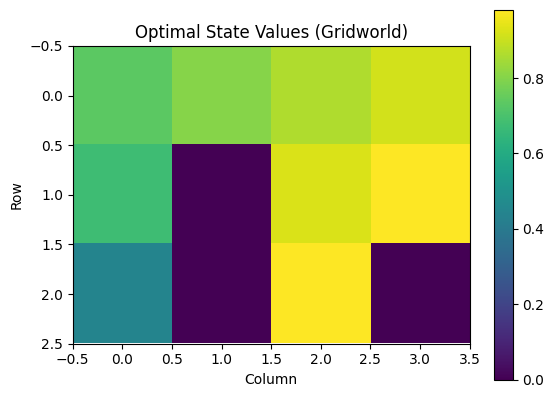

Greedy policy (arrows). T=terminal, #=wall
 →  →  ↓  ↓
 ↑  #  ↓  ↓
 ↑ T-  → T+


In [ ]:

# Build the MDP
mdp, s_plus, s_minus, s_wall = build_gridworld_mdp(rows=3, cols=4, gamma=0.99, slip=0.1)

# Solve with Value Iteration
V, pi, iters = value_iteration(mdp, theta=1e-10, max_iters=10000)
print(f"Converged in {iters} iterations.")

# Pretty-print value function as a grid
rows, cols = 3, 4
V_grid = np.zeros((rows, cols))
for r in range(rows):
    for c in range(cols):
        V_grid[r, c] = V.get((r,c), 0.0)

# Show value heatmap (no explicit colors specified)
plt.figure()
plt.title("Optimal State Values (Gridworld)")
plt.imshow(V_grid, origin='upper')
plt.colorbar()
plt.xlabel("Column")
plt.ylabel("Row")
plt.show()

# Display the greedy policy arrows (skip terminals and wall)
arrow = {'up':'↑', 'down':'↓', 'left':'←', 'right':'→'}
print("Greedy policy (arrows). T=terminal, #=wall")
for r in range(rows):
    row_syms = []
    for c in range(cols):
        s = (r,c)
        if s == s_wall:
            row_syms.append("#")
        elif s == s_plus:
            row_syms.append("T+")
        elif s == s_minus:
            row_syms.append("T-")
        else:
            a = pi.get(s, None)
            row_syms.append(arrow.get(a, "."))
    print(" ".join(f"{x:>2}" for x in row_syms))


In [ ]:

# Convert greedy policy to deterministic mapping for simulation
det_pi = {s: a for s, a in pi.items()}

# Simulate from a few start states
start_states = [(0,0), (1,0), (2,0)]
for s0 in start_states:
    traj, G = simulate_episode(mdp, det_pi, start_state=s0, max_steps=50)
    print(f"\nStart: {s0}, Return: {G:.3f}, Steps: {len(traj)}")
    for (s,a,r,sp) in traj:
        print(f"s={s} --{a}--> s'={sp}, r={r:+.2f}")



Start: (0, 0), Return: 0.707, Steps: 7
s=(0, 0) --right--> s'=(1, 0), r=-0.04
s=(1, 0) --up--> s'=(0, 0), r=-0.04
s=(0, 0) --right--> s'=(0, 1), r=-0.04
s=(0, 1) --right--> s'=(0, 2), r=-0.04
s=(0, 2) --down--> s'=(1, 2), r=-0.04
s=(1, 2) --down--> s'=(2, 2), r=-0.04
s=(2, 2) --right--> s'=(2, 3), r=+1.00

Start: (1, 0), Return: 0.660, Steps: 8
s=(1, 0) --up--> s'=(0, 0), r=-0.04
s=(0, 0) --right--> s'=(0, 1), r=-0.04
s=(0, 1) --right--> s'=(0, 2), r=-0.04
s=(0, 2) --down--> s'=(0, 1), r=-0.04
s=(0, 1) --right--> s'=(0, 2), r=-0.04
s=(0, 2) --down--> s'=(1, 2), r=-0.04
s=(1, 2) --down--> s'=(2, 2), r=-0.04
s=(2, 2) --right--> s'=(2, 3), r=+1.00

Start: (2, 0), Return: 0.707, Steps: 7
s=(2, 0) --up--> s'=(1, 0), r=-0.04
s=(1, 0) --up--> s'=(0, 0), r=-0.04
s=(0, 0) --right--> s'=(0, 1), r=-0.04
s=(0, 1) --right--> s'=(0, 2), r=-0.04
s=(0, 2) --down--> s'=(1, 2), r=-0.04
s=(1, 2) --down--> s'=(2, 2), r=-0.04
s=(2, 2) --right--> s'=(2, 3), r=+1.00



## Minimal 3-State MDP (Extra)

To further clarify Value Iteration, here is a tiny 3-state MDP. You can modify rewards and transition probabilities to see how the optimal policy changes.


In [ ]:

# Define a tiny 3-state MDP with actions {a,b}
S = ['s0', 's1', 's2']
A = ['a', 'b']
mdp_small = TabularMDP(states=S, actions=A, gamma=0.95)

# Transitions for action 'a'
# From s0: 70% -> s1 with reward +1, 30% -> s2 with reward 0
mdp_small.add_transition('s0','a',0.7,'s1',+1.0,False)
mdp_small.add_transition('s0','a',0.3,'s2',+0.0,False)
# From s1 under 'a': go to s2 with +2 (deterministic)
mdp_small.add_transition('s1','a',1.0,'s2',+2.0,False)
# From s2 under 'a': terminal self-loop with 0 (treat as terminal-like)
mdp_small.add_transition('s2','a',1.0,'s2',0.0,True)

# Transitions for action 'b'
# From s0 under 'b': go to s1 with +0.5
mdp_small.add_transition('s0','b',1.0,'s1',+0.5,False)
# From s1 under 'b': stay in s1 with -0.1 (loop)
mdp_small.add_transition('s1','b',1.0,'s1',-0.1,False)
# From s2 under 'b': terminal with 0
mdp_small.add_transition('s2','b',1.0,'s2',0.0,True)

V_s, pi_s, it_s = value_iteration(mdp_small, theta=1e-10, max_iters=10000)
print(f"Small MDP converged in {it_s} iterations.")
print("Values:", V_s)
print("Greedy policy:", pi_s)

# Simulate a few episodes from s0 under optimal policy
det_pi_small = {s:a for s,a in pi_s.items()}
for i in range(3):
    traj, G = simulate_episode(mdp_small, det_pi_small, start_state='s0', max_steps=20)
    print(f"Episode {i+1}: Return={G:.3f}, Steps={len(traj)}")
    for (s,a,r,sp) in traj:
        print(f"  {s} --{a}--> {sp}, r={r:+.2f}")


Small MDP converged in 3 iterations.
Values: {'s0': 2.4, 's1': 2.0, 's2': 0.0}
Greedy policy: {'s0': 'b', 's1': 'a'}
Episode 1: Return=2.400, Steps=2
  s0 --b--> s1, r=+0.50
  s1 --a--> s2, r=+2.00
Episode 2: Return=2.400, Steps=2
  s0 --b--> s1, r=+0.50
  s1 --a--> s2, r=+2.00
Episode 3: Return=2.400, Steps=2
  s0 --b--> s1, r=+0.50
  s1 --a--> s2, r=+2.00



## Tips & Next Steps

- Try different discount factors (e.g., `gamma=0.9`) or different slip probabilities.
- Change the step penalty to see how paths shorten/lengthen.
- Implement **Policy Iteration** and compare the number of iterations to converge.
- Add **epsilon-greedy** exploration and run **Q-learning** on the same grid to compare results with Value Iteration.
